# Implementing a 1D CNN

This notebook is a beginner-friendly guide to building a 1D Convolutional Neural Network (CNN) in Python. It breaks the model into clear, self-contained functions, starting from basic convolution operations to constructing a simple CNN architecture. Each function is designed to be easy to understand and implement, making it suitable for those new to deep learning and CNNs.

## Convolution

A convolution is an integral that expresses the amount of overlap of one function $g$ as it is reflected and moved over another function $f$. It therefore "blends" one function with another. Where $f$ is often referred to as the input signal and $g$ as the kernel or filter.

The formula of convolution for continuous functions is given by:
$$
(f * g)(t) = \int_{-\infty}^{\infty} f(\tau) g(t - \tau) d\tau
$$ 

Intuition:
Imagine sliding a "window" (the filter $g$) across your input signal ($f$). At every step of the slide (represented by time $t$), you calculate the product of the two overlapping shapes and then sum all those values up. This sum becomes the value of the new function at that point.

Let's take a simple 1D example obtained by convolving two box signals, the obtained result (black line) will be a function that at each spatial coordinate $x$ associates the area of overlap of the two signals as one is shifted over the other ($y$ axis shows the amplitude of the convolution result).

<p align="center">
  <img src="Convolution_of_box_signal_with_itself2.gif" width="500">
</p>

### Python Implementation: `apply_convolution`

The `apply_convolution` function implements this "sliding window" operation. In the context of Convolutional Neural Networks (CNNs), this operation detects how well the input signal matches the pattern stored in the filter at every position.

#### Parameters
* **`input_data` ($f$):** A 2D numpy array representing the input signal.
    * *Shape:* `(num_channels, input_length)`
    * *Math connection:* This corresponds to the function $f(\tau)$ in our formula.
* **`filters` ($g$):** A list of 2D numpy arrays acting as our kernels.
    * *Shape:* Each filter has shape `(num_channels, kernel_size)`.
    * *Math connection:* These correspond to the function $g$ that we slide across $f$.
* **`stride`:** An integer indicating the step size of the slide.
    * *Default:* 1.
    * *Math connection:* This determines the discrete intervals of $t$ (time/position) at which we compute the integral. A stride of 2 means we skip every other position $t$.

#### Returns
* **`output`:** A 2D numpy array representing the convolved feature map.
    * *Shape:* `(num_filters, output_length)`
    * *Math connection:* This is the resulting function $(f * g)(t)$.

#### Function Logic (Step-by-Step)

1.  **Input Validation:**
    First, ensure the `input_data` and `filters` dimensions are compatible. The number of channels in the filter must match the number of channels in the input (just as $f$ and $g$ must operate in the same domain).

2.  **Initialize Output:**
    Create an empty array to store the result. The number of rows will equal the number of filters provided.

3.  **Calculate Output Dimensions:**
    Determine the length of the output sequence. This depends on the input length $L$, the filter size $K$, and the stride $S$. The relationship is:
    $$\text{Output Length} = \lfloor \frac{L - K}{S} \rfloor + 1$$

4.  **The "Sliding Window" Loop (The Convolution):**
    This is the core mathematical operation implemented in a loop:
    * **The Shift ($t$):** Iterate through the input data with a step size defined by `stride`. This loop index represents the variable $t$ in the formula.
    * **The Overlap ($f \cdot g$):** Extract the current "slice" or window of the input data that overlaps with the filter. Perform an **element-wise multiplication** between the filter and this input slice. This corresponds to the term $f(\tau)g(t-\tau)$.
    * **The Integral ($\sum$):** Sum all the values in that product to get a single number. This summation approximates the integral $\int ... d\tau$.
    * Store this scalar value in the `output` array at the current position.

5.  **Finalize:**
    Return the `output` array, which now contains the "blended" signal showing where the filter's pattern appeared most strongly in the input.

---

### Math-to-Code Translation Table

| Mathematical Concept | Python Implementation |
| :--- | :--- |
| **Shift variable ($t$)** | The `for` loop index (multiplied by stride) |
| **Dummy variable ($\tau$)** | The array indices inside the filter/window |
| **$f(\tau) \cdot g(t-\tau)$** | `input_slice * filter` (Element-wise multiplication) |
| **$\int ... d\tau$** | `np.sum(...)` (Summation over all channels/elements) |


Input your code where indicated

In [ ]:
# Import necessary libraries
import numpy as np

# Function 1: Convolution
def apply_convolution(input_data, filters, stride=1):
    """
    Apply convolution on a 3D input using given filters.

    Parameters:
    - input_data: 2D numpy array, the input data (channels, length)
    - filters: List of 2D numpy arrays, representing the filters
    - stride: Integer, the stride of the convolution operation

    Returns:
    - output: 2D numpy array, the result of convolution
    """

    # Ensure filters are the right shape
    ## YOUR CODE HERE (Hint: assert might be useful here)

    # Initialize an empty array to store the convolution result
    output_len = ## YOUR CODE HERE # integer division is like floor operation
    num_filters = ## YOUR CODE HERE
    output = ## YOUR CODE HERE 

    # Perform convolution with the specified stride
    for i in range(output_len): # Loop over output length
        ## YOUR CODE HERE 
    return output

In [2]:
# quick debug
input_data = np.random.rand(3, 10)  # Example input data with 3 channels and length 10
filters = [np.random.rand(3, 3) for _ in range(2)]
output = apply_convolution(input_data, filters, stride=2)

out_len = (input_data.shape[1] - filters[0].shape[1]) // 2 + 1

print(output.shape[1] == out_len) # Should be True
print("Expected output length:", out_len)
print("Output shape:", output.shape) # Should be (number of filters, output length)
print("Output:", output) # Display the output array


True
Expected output length: 4
Output shape: (2, 4)
Output: [[3.03233545 2.64801829 2.3262078  2.94274479]
 [1.62654178 1.46615166 1.12284317 1.64714419]]


### Edge Detection Filter

In signal processing, convolution is fundamental for feature extraction, pattern recognition, and data analysis.
One of the simplest and most common filters is the edge detection filter. It highlights areas of the image where there are significant changes in intensity, which often correspond to edges.
Coming back to the function conceptualisation, an edge is a place where the intensity values change rapidly. In other words, the derivative of the intensity function is high. The resulting feature map will have spikes where the derivative of the original signal is high (steep slope of the function), indicating edges.

The idea here is to create a filter that approximates the derivative of the signal intensity function. A simple way to do this is to use a filter that subtracts the intensity of neighboring pixels. The higher the difference, the stronger the response of the filter, indicating a potential edge. So the resulting feature map will have high values (bright pixels) at edges and low values elsewhere.

![Edge Detection Illustration](edgedetection.png)

In the image above, the our original image is represented in the first two illustrations. The third illustration shows the effect of applying the edge detection filter. Notice how edges are highlighted while other areas are suppressed.

Let's implement this in code.

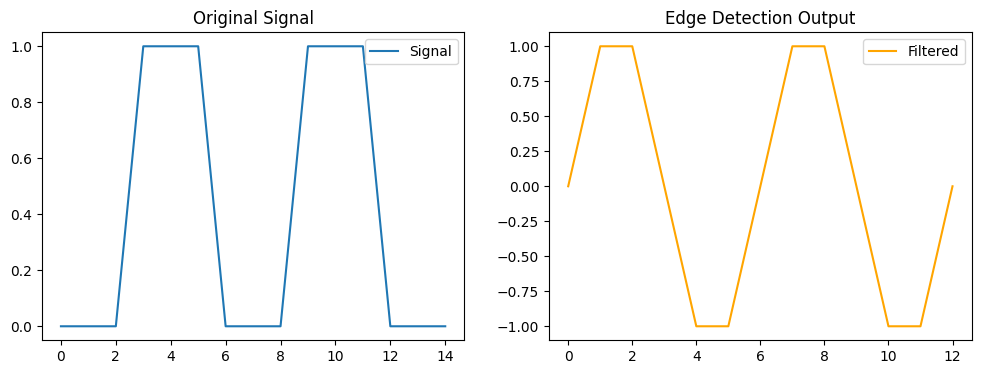

In [ ]:
# 1D Edge Detection Example 
import matplotlib.pyplot as plt

# Create a simple 1D signal with edges
signal = np.array([[0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0]])  # Shape: (1, 15) - added channel dimension
# Define a simple edge detection filter
edge_filter = ## YOUR CODE HERE (Hint: we want to detect DIFFERENCES in value)
filters = [edge_filter]
# Apply convolution
output = apply_convolution(signal, filters)

# Plotting
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.title("Original Signal")
plt.plot(signal[0], label="Signal")  # Plot first channel
plt.legend()

plt.subplot(1, 2, 2)
plt.title("Edge Detection Output")
plt.plot(output[0], label="Filtered", color='orange')  # Plot first channel
plt.legend()

plt.show()

Let's see how our edge detection filter works on a different 1D edges.

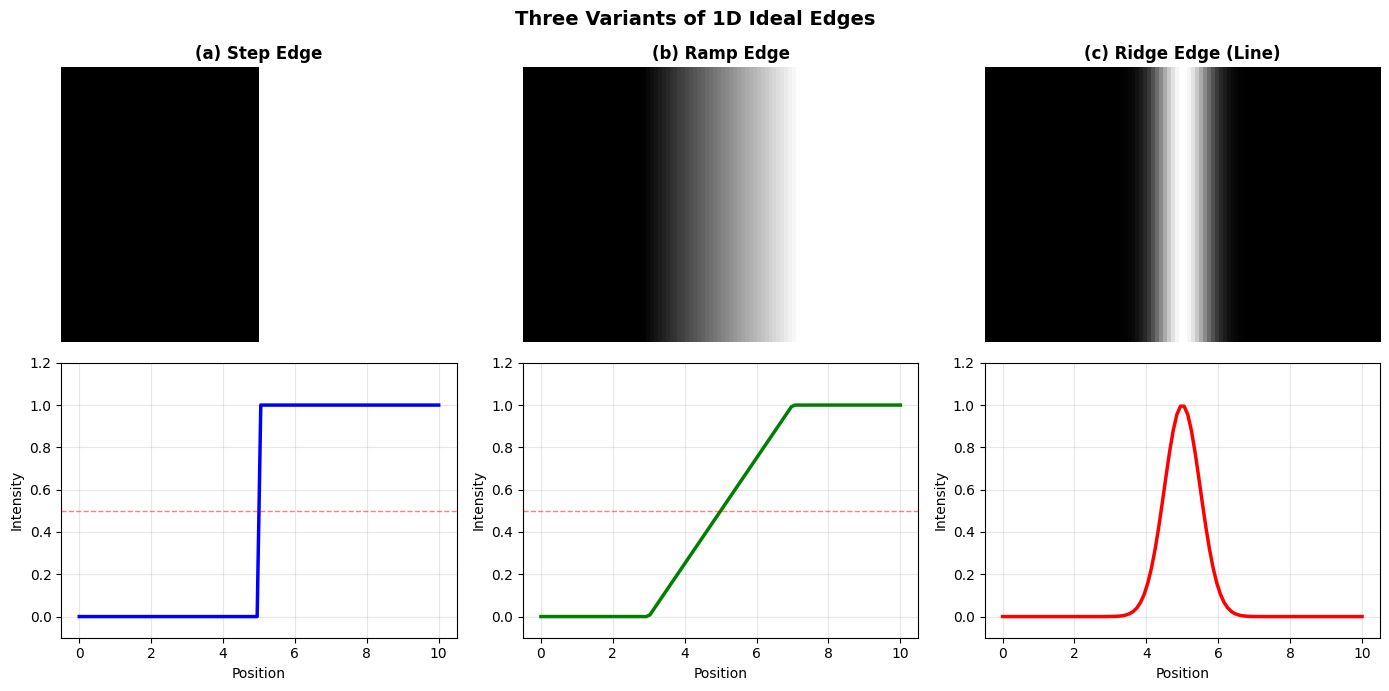

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Create x-axis
x = np.linspace(0, 10, 100)

# Define three edge types
# (a) Step edge
step_edge = np.where(x < 5, 0, 1)

# (b) Ramp edge
ramp_edge = np.clip((x - 3) / 4, 0, 1)

# (c) Ridge edge (spike)
ridge_edge = np.exp(-((x - 5)**2) / 0.5)

def plot_ideal_edges(x, step_edge, ramp_edge, ridge_edge):
    """
    Plots three variants of 1D ideal edges with corresponding intensity profiles.
    (a) Step edge
    (b) Ramp edge
    (c) Ridge edge
    """
    # Create figure with 2 rows and 3 columns
    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    
    # ===== STEP EDGE (a) =====
    # Intensity gradient visualization
    gradient_step = np.tile(step_edge, (20, 1))
    axes[0, 0].imshow(gradient_step, cmap='gray', aspect='auto')
    axes[0, 0].set_title('(a) Step Edge', fontsize=12, fontweight='bold')
    axes[0, 0].axis('off')
    
    # 1D profile
    axes[1, 0].plot(x, step_edge, 'b-', linewidth=2.5)
    axes[1, 0].set_xlabel('Position', fontsize=10)
    axes[1, 0].set_ylabel('Intensity', fontsize=10)
    axes[1, 0].set_ylim(-0.1, 1.2)
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, linewidth=1)
    
    # ===== RAMP EDGE (b) =====
    # Intensity gradient visualization
    gradient_ramp = np.tile(ramp_edge, (20, 1))
    axes[0, 1].imshow(gradient_ramp, cmap='gray', aspect='auto')
    axes[0, 1].set_title('(b) Ramp Edge', fontsize=12, fontweight='bold')
    axes[0, 1].axis('off')
    
    # 1D profile
    axes[1, 1].plot(x, ramp_edge, 'g-', linewidth=2.5)
    axes[1, 1].set_xlabel('Position', fontsize=10)
    axes[1, 1].set_ylabel('Intensity', fontsize=10)
    axes[1, 1].set_ylim(-0.1, 1.2)
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, linewidth=1)
    
    # ===== RIDGE EDGE (c) =====
    # Intensity gradient visualization
    gradient_ridge = np.tile(ridge_edge, (20, 1))
    axes[0, 2].imshow(gradient_ridge, cmap='gray', aspect='auto')
    axes[0, 2].set_title('(c) Ridge Edge (Line)', fontsize=12, fontweight='bold')
    axes[0, 2].axis('off')
    
    # 1D profile
    axes[1, 2].plot(x, ridge_edge, 'r-', linewidth=2.5)
    axes[1, 2].set_xlabel('Position', fontsize=10)
    axes[1, 2].set_ylabel('Intensity', fontsize=10)
    axes[1, 2].set_ylim(-0.1, 1.2)
    axes[1, 2].grid(True, alpha=0.3)
    
    # Add main title
    fig.suptitle('Three Variants of 1D Ideal Edges', 
                 fontsize=14, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    plt.show()

# Call the function
plot_ideal_edges(x, step_edge, ramp_edge, ridge_edge)

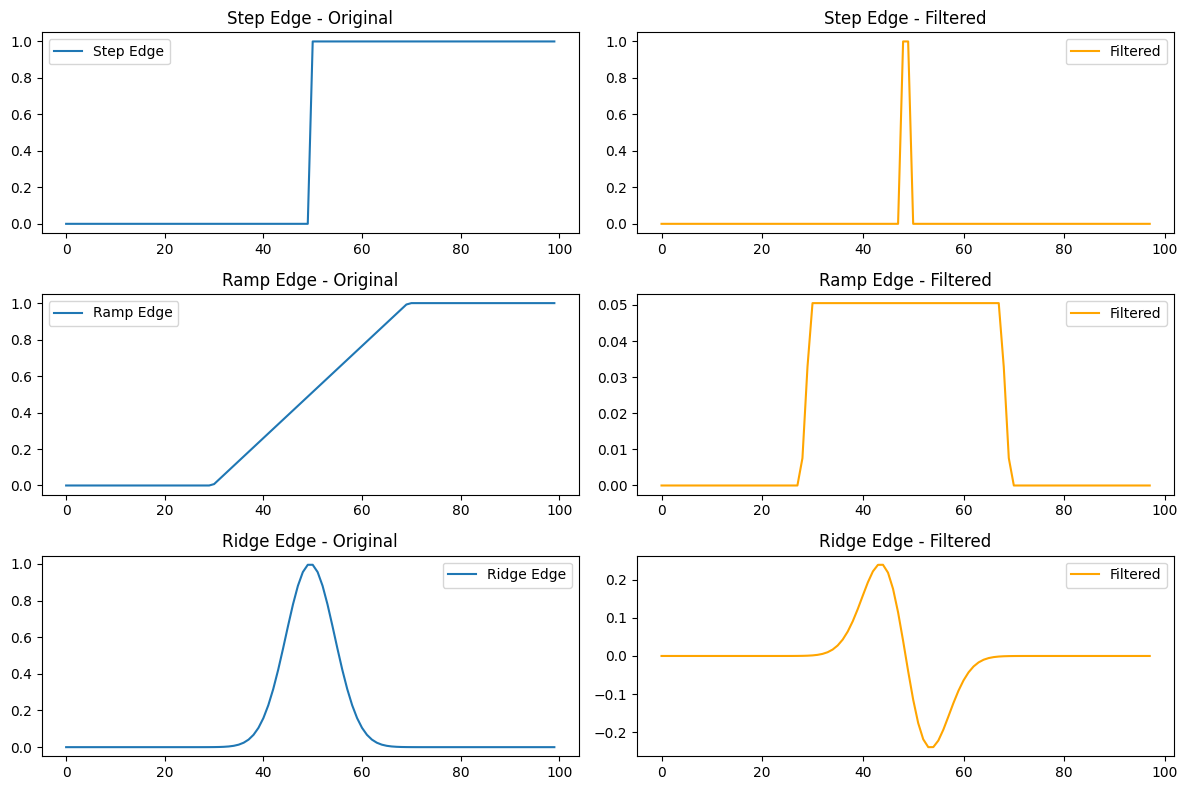

In [ ]:
# apply edge detection filter on diff 1D edges 

# Step edge
out_step = ## YOUR CODE HERE  (Hint:  Reshape to add channel dimension)

# Ramp edge
out_ramp = ## YOUR CODE HERE

# Ridge edge
out_ridge = ## YOUR CODE HERE

# Plotting the results
plt.figure(figsize=(12, 8))
plt.subplot(3, 2, 1)
plt.title("Step Edge - Original")
plt.plot(step_edge, label="Step Edge")
plt.legend()
plt.subplot(3, 2, 2)
plt.title("Step Edge - Filtered")
plt.plot(out_step[0], label="Filtered", color='orange')
plt.legend()
plt.subplot(3, 2, 3)
plt.title("Ramp Edge - Original")
plt.plot(ramp_edge, label="Ramp Edge")
plt.legend()
plt.subplot(3, 2, 4)
plt.title("Ramp Edge - Filtered")
plt.plot(out_ramp[0], label="Filtered", color='orange')
plt.legend()
plt.subplot(3, 2, 5)
plt.title("Ridge Edge - Original")
plt.plot(ridge_edge, label="Ridge Edge")
plt.legend()
plt.subplot(3, 2, 6)
plt.title("Ridge Edge - Filtered")
plt.plot(out_ridge[0], label="Filtered", color='orange')
plt.legend()
plt.tight_layout()
plt.show()



## Pooling:

As we have discussed so far, the main idea behind convolution is extracting spatial features from different positions in the input data. However, after convolution, the resulting feature maps can still be quite large, which can lead to high computational costs and sparsity.
Pooling is a downsampling technique used in convolutional neural networks (CNNs) to reduce the spatial dimensions of an input volume while retaining the most important features.
It works by sliding a fixed-size window across the input feature map with a specified stride, often equal to the window size for non-overlapping regions, and selecting the maximum value within each window to produce a single output value.

<p align="center">
  <img src="Image_max_pooling.webp" width="500">
</p>

This process reduces the number of parameters and computations in the network, helping to prevent overfitting and accelerate training.
The operation is performed independently for each channel in the input, resulting in a smaller, more manageable representation that maintains key features and provides some degree of translation invariance, meaning the model can recognize features regardless of their precise location in the input.

### Parameters:
- **input_data:** A numpy array representing the input data.
- **pool_size:** An integer indicating the size of the pooling window. It determines how many elements are considered in each pooling operation.
- **stride:** An integer indicating the step size or stride of the pooling operation. The default value is 1, meaning the pooling window moves one element at a time.

### Returns:
- **result:** A numpy array representing the result after pooling. The dimensions of the result are determined by the number of rows in the input data and the length of the resulting pooled sequence.

### Function Logic:

1. The output length after pooling is calculated based on the input data dimensions, pool size, and the specified stride.

2. An empty array (`result`) is initialized to store the pooling result. The dimensions of this array are determined by the number of rows in the input data and the calculated output length.

3. A loop iterates through the input data, applying 1D pooling with the specified stride. The maximum value within each pooling window is computed using the `np.max` function along axis 1.

4. The final output is a 1D or 2D numpy array representing the result after pooling.

You are expected to complete the function by implementing the 1D pooling operation with the given pool size and stride. The completed function will be an essential component in building a pooling layer for a neural network, aiding in feature extraction and dimensionality reduction. 
**Simpler variation:**
You can build a simpler approach first by ignoring the stride and assuming it is always 1.

In [ ]:
# Function 2: 1D Pooling
def apply_pooling(input_data, pool_size, stride=1):
    """
    Apply 1D pooling on the input data.

    Parameters:
    - input_data: 2D numpy array, the input data
    - pool_size: Integer, size of the pooling window
    - stride: Integer, the stride of the pooling operation

    Returns:
    - result: 2D numpy array, the result after pooling
    """
    # Ensure the input is a 1D or 2D array
    ## YOUR CODE HERE (remember to check ndim)

    # Calculate the output length after pooling
    output_length = ## YOUR CODE HERE

    # Initialize an empty array to store the pooling result
    result = ## YOUR CODE HERE

    # Perform 1D pooling with the specified stride
    for i in range(output_length):
        result[:, i] = ## YOUR CODE HERE

    return result

In [7]:
# quick debug
input_data = np.random.rand(2, 15)  # Example input data with 2 channels and length 15
pool_size = 3
stride = 2
output = apply_pooling(input_data, pool_size, stride)

expected_out_len = (input_data.shape[1] - pool_size) // stride + 1

print(output.shape[1] == expected_out_len)  # Should be True
print("Expected output length:", expected_out_len)
print("Output shape:", output.shape)  # Should be (num_channels, output_length)
print("Output:", output)  # Display the output array

True
Expected output length: 7
Output shape: (2, 7)
Output: [[0.77957987 0.36582737 0.71809403 0.71809403 0.99217566 0.99217566
  0.62814433]
 [0.32679651 0.89342177 0.89342177 0.99770299 0.99394342 0.99394342
  0.91208868]]


Let's now see how pooling affects our previous edge detection example.

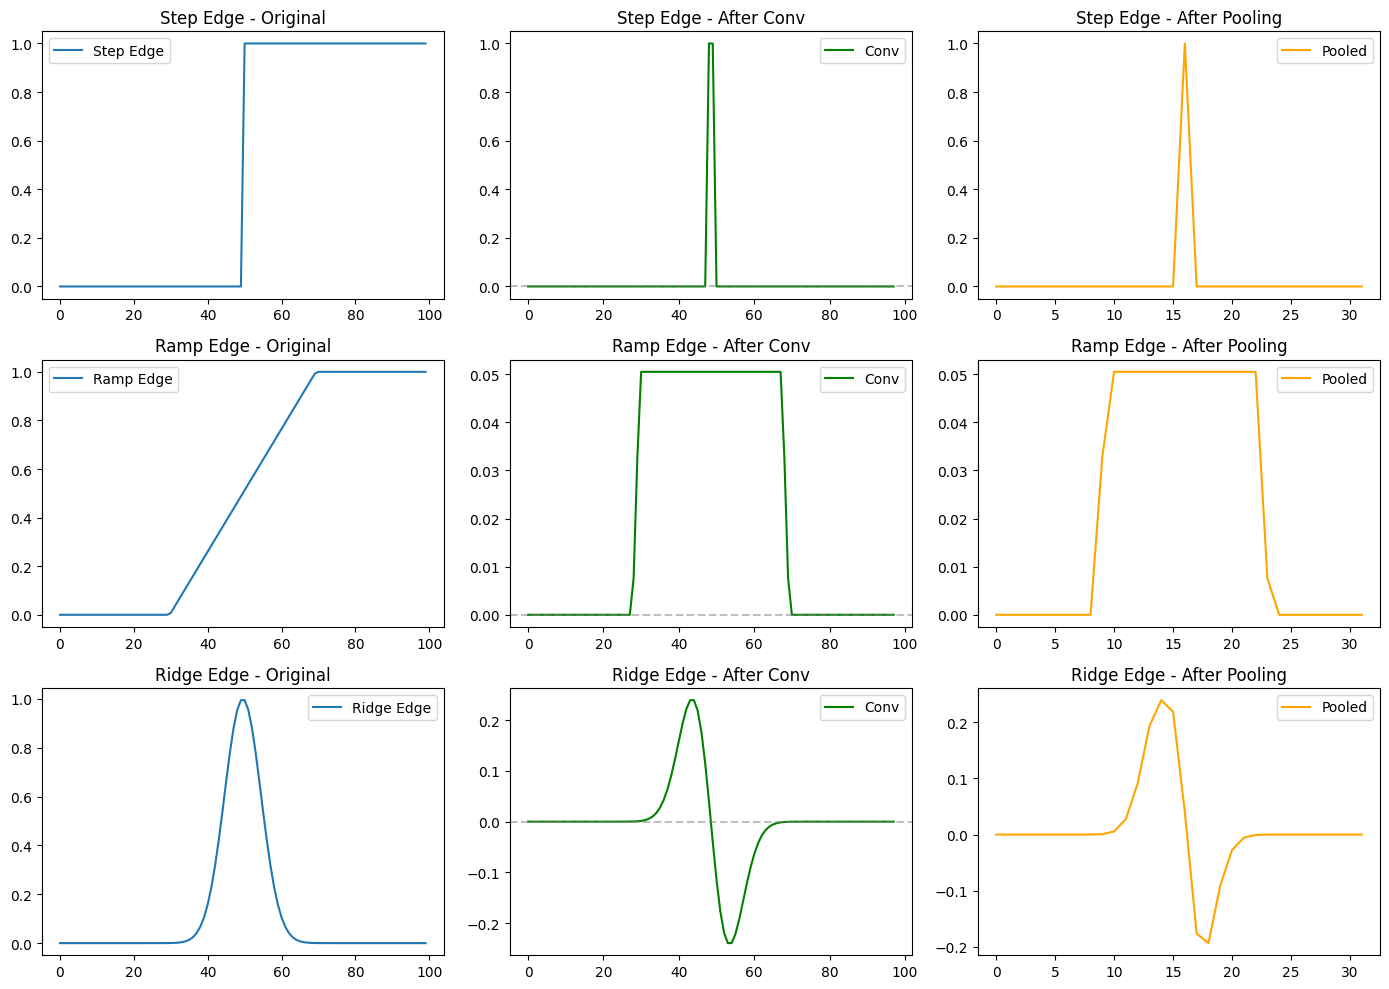

In [ ]:
# Step edge 
conv_step = ## YOUR CODE HERE
pool_step = ## YOUR CODE HERE 

# Ramp edge
conv_ramp = ## YOUR CODE HERE
pool_ramp = ## YOUR CODE HERE

# Ridge edge
conv_ridge = ## YOUR CODE HERE
pool_ridge = ## YOUR CODE HERE

# Plotting the results
plt.figure(figsize=(14, 10))

# Step edge
plt.subplot(3, 3, 1)
plt.title("Step Edge - Original")
plt.plot(step_edge, label="Step Edge")
plt.legend()
plt.subplot(3, 3, 2)
plt.title("Step Edge - After Conv")
plt.plot(conv_step[0], label="Conv", color='green')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.legend()
plt.subplot(3, 3, 3)
plt.title("Step Edge - After Pooling")
plt.plot(pool_step[0], label="Pooled", color='orange')
plt.legend()

# Ramp edge
plt.subplot(3, 3, 4)
plt.title("Ramp Edge - Original")
plt.plot(ramp_edge, label="Ramp Edge")
plt.legend()
plt.subplot(3, 3, 5)
plt.title("Ramp Edge - After Conv")
plt.plot(conv_ramp[0], label="Conv", color='green')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.legend()
plt.subplot(3, 3, 6)
plt.title("Ramp Edge - After Pooling")
plt.plot(pool_ramp[0], label="Pooled", color='orange')
plt.legend()

# Ridge edge
plt.subplot(3, 3, 7)
plt.title("Ridge Edge - Original")
plt.plot(ridge_edge, label="Ridge Edge")
plt.legend()
plt.subplot(3, 3, 8)
plt.title("Ridge Edge - After Conv")
plt.plot(conv_ridge[0], label="Conv", color='green')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.legend()
plt.subplot(3, 3, 9)
plt.title("Ridge Edge - After Pooling")
plt.plot(pool_ridge[0], label="Pooled", color='orange')
plt.legend()

plt.tight_layout()
plt.show()

# 1D CNN:

Now that you are familiar with the concept of convolution and filtering, and we have looked at what extracted features (edges) might look like, the concept of a convolutional neural network (CNN) comes into play.
A CNN is a type of deep learning model designed to automatically and adaptively learn features from input data, extracting relevant information for the task at hand. The 'magic' trick is that we don't have to specify which kind of filters to use; instead, the network learns the optimal filters during training.

## ReLU
One last operation we might need to implement before building the CNN is to include nonlinear activation functions, such as ReLU (Rectified Linear Unit). ReLU introduces non-linearity into the model, allowing it to learn complex patterns. The ReLU function outputs the input directly if it is positive; otherwise, it outputs zero.

In [ ]:
# Function 3: ReLU Activation
def apply_relu(input_data):
    """
    Apply ReLU activation on the input data.

    Parameters:
    - input_data: 2D numpy array, the input data

    Returns:
    - result: 2D numpy array, the result after applying ReLU
    """
    # Apply ReLU activation element-wise 

    return ## YOUR CODE HERE

In [10]:
# quick debug test

input_data = np.array([[-1, 2, -3], [4, -5, 6]])
output = apply_relu(input_data)
print("Input:\n", input_data)
print("Output after ReLU:\n", output) # all negative values should be 0

Input:
 [[-1  2 -3]
 [ 4 -5  6]]
Output after ReLU:
 [[0 2 0]
 [4 0 6]]


## 1D CNN Function

The `one_dimensional_cnn` function is designed to create a 1D Convolutional Neural Network (CNN) with two convolutional layers, ReLU activation, and pooling. This function should allow you to implement and understand the composition of a simple CNN architecture, combining convolution, activation, and pooling layers.

### Parameters:
- **input_data:** A numpy array representing the input data. It should be a 2D array.
- **filters_layer1:** A list of 2D numpy arrays representing the filters for the first convolutional layer.
- **filters_layer2:** A list of 2D numpy arrays representing the filters for the second convolutional layer.
- **pool_size:** An integer indicating the size of the pooling window. It determines how many elements are considered in each pooling operation.
- **conv_stride:** An integer indicating the stride of the convolution operation. The default value is 1.
- **pool_stride:** An integer indicating the stride of the pooling operation. The default value is 1.

### Returns:
- **output:** A 2D numpy array representing the final output of the CNN after the application of convolution, ReLU activation, and pooling.

### Function Logic:
1. The function should start by applying convolution and ReLU activation for the first layer (`layer1_output`), followed by 1D pooling (`layer1_output_pooled`).

2. Then, it should apply convolution and ReLU activation for the second layer (`layer2_output`), followed by 1D pooling (`layer2_output_pooled`).

3. The final output (`layer2_output_pooled`) will represent the result of the complete CNN architecture.

4. Print the intermediate steps to see the process between operations.

In [ ]:

# Function 4: 1D CNN
def one_dimensional_cnn(input_data, filters_layer1, filters_layer2, pool_size, conv_stride=1, pool_stride=1):
    """
    Create a 1D CNN with two convolutional layers, ReLU activation, and pooling.

    Parameters:
    - input_data: 2D numpy array, the input data
    - filters_layer1: List of 2D numpy arrays, filters for the first convolutional layer
    - filters_layer2: List of 2D numpy arrays, filters for the second convolutional layer
    - pool_size: Integer, size of the pooling window

    Returns:
    - output: 2D numpy array, the final output of the CNN
    """
    # Apply convolution and ReLU activation for the first layer
    layer1_output = apply_convolution(input_data, filters_layer1, conv_stride)
    layer1_output_relu = apply_relu(layer1_output)
    layer1_output_pooled = apply_pooling(layer1_output_relu, pool_size, pool_stride)

    # Apply convolution and ReLU activation for the second layer
    layer2_output = apply_convolution(layer1_output_pooled, filters_layer2, conv_stride)
    layer2_output_relu = apply_relu(layer2_output)
    layer2_output_pooled = apply_pooling(layer2_output_relu, pool_size, pool_stride)

    np.set_printoptions(precision=2, suppress=True)
    print(f"Input data: {input_data}\n")
    print(f"Output convolution 1:\n{layer1_output}")
    print(f"ReLU 1:\n{layer1_output_relu}")
    print(f"Pooling 1:\n{layer1_output_pooled}\n")
    print(f"Output convolution 2:\n{layer2_output}")
    print(f"ReLU 2:\n{layer2_output_relu}")
    print(f"Pooling 2:\n{layer2_output_pooled}\n")

    return layer2_output_pooled

Now we can create some input parameters and call the function.
For the sample parameters below, your output should be: [[7. 7. 0. 1. 1.]]

In [12]:
# Example Usage
input_data = np.array([[1, 5, 3, 7, 5, 3, 5, 6, 9, 1]])  # Example 1D input
filters_layer1 = [np.array([[1, -1, 1]]),
                  np.array([[1, -3, 2]])]
filters_layer2 = [np.array([[-2, 1], [2, -1]])]
pool_size = 2

output = one_dimensional_cnn(input_data, filters_layer1, filters_layer2, pool_size)
print("Final Output:", output)

Input data: [[1 5 3 7 5 3 5 6 9 1]]

Output convolution 1:
[[ -1.   9.   1.   5.   7.   4.   8.  -2.]
 [ -8.  10.  -8.  -2.   6.   0.   5. -19.]]
ReLU 1:
[[ 0.  9.  1.  5.  7.  4.  8.  0.]
 [ 0. 10.  0.  0.  6.  0.  5.  0.]]
Pooling 1:
[[ 9.  9.  5.  7.  7.  8.  8.]
 [10. 10.  0.  6.  6.  5.  5.]]

Output convolution 2:
[[ 1.  7. -9. -1.  1. -3.]]
ReLU 2:
[[1. 7. 0. 0. 1. 0.]]
Pooling 2:
[[7. 7. 0. 1. 1.]]

Final Output: [[7. 7. 0. 1. 1.]]


## 2D CNN

Let's now use our knowledge to build a 2D variation of our CNN

To do this, we will first load a sample 2D image and then modify our previous functions to handle 2D convolutions and pooling.

## Preprocessing the Image

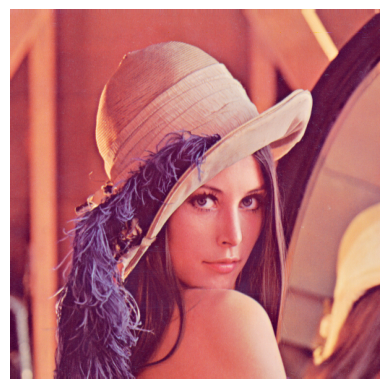

Image shape: (512, 512, 3)


In [ ]:
# first let's load and visualize an image (we'll use a famous img :P)

img_path = 'Lenna_(test_image).png'

# load and plot the image
from skimage import io, color # If required, install scikit-image with pip install -U scikit-image
import matplotlib.pyplot as plt
img = io.imread(img_path)
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

# let's print the shape of the image
print("Image shape:", img.shape)  # Should print (512, 512, 3) since it's a RGB image (1 channel per color red-green-blue)

If we could zoom in on the image we would see that now it is made up of tiny squares called pixels, each with its own RGB color value.
Let's print a few pixel values to see this more clearly.

In [ ]:
# print three matrices (rgb channels) for a 5x5 patch of the image starting in the position defined by x and y.
x, y = 100, 150  # top-left corner of the patch

patch = ## YOUR CODE HERE # we take all 3 channels
print("5x5 Patch RGB values:") # print one channel at a time (each value between 0-255 represents intensity)
print("Red channel:\n", ## YOUR CODE HERE)
print("Green channel:\n", ## YOUR CODE HERE)
print("Blue channel:\n", ## YOUR CODE HERE)

# let's plot the patch
plt.imshow(patch)
plt.axis('off')
plt.show()


5x5 Patch RGB values:
Red channel:
 [[186 182 183 184 181]
 [184 186 183 184 183]
 [190 189 181 185 188]
 [184 188 189 190 182]
 [189 185 190 187 188]]
Green channel:
 [[76 73 73 74 79]
 [76 88 84 80 78]
 [77 83 79 82 80]
 [82 74 80 89 80]
 [87 90 79 83 77]]
Blue channel:
 [[90 89 85 77 93]
 [92 99 92 86 94]
 [81 92 87 88 89]
 [92 87 83 96 93]
 [93 93 81 94 83]]


/opt/miniconda3/envs/DL/lib/python3.13/site-packages/skimage/color/colorconv.py:984: RuntimeWarning: divide by zero encountered in matmul
  return rgb @ coeffs
/opt/miniconda3/envs/DL/lib/python3.13/site-packages/skimage/color/colorconv.py:984: RuntimeWarning: overflow encountered in matmul
  return rgb @ coeffs
/opt/miniconda3/envs/DL/lib/python3.13/site-packages/skimage/color/colorconv.py:984: RuntimeWarning: invalid value encountered in matmul
  return rgb @ coeffs


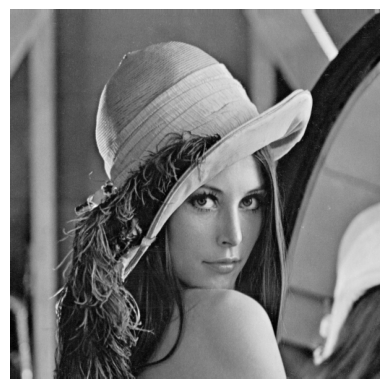

Grayscale image shape: (512, 512)


In [ ]:
# let's convert it to grayscale and normalize it, so that pixel values are between 0 and 1

# convert to grayscale, using color module from skimage
img_gray = ## YOUR CODE HERE # converts to grayscale and normalizes between 0-1
plt.imshow(img_gray, cmap='gray')
plt.axis('off')
plt.show()

print("Grayscale image shape:", ## YOUR CODE HERE)  # Should print (512, 512), we now only have one channel for intensity 0-1

In [ ]:
# let's print the same patch to see the effects of grayscale conversion and normalization
x, y = 100, 150  # top-left corner of the patch
patch_g = ## YOUR CODE HERE 
print("5x5 Patch values:\n", ## YOUR CODE HERE) # print one channel at a time (each value between 0-1 represents intensity)

5x5 Patch values:
 [[0.39 0.38 0.38 0.38 0.4 ]
 [0.39 0.43 0.41 0.4  0.4 ]
 [0.4  0.42 0.4  0.41 0.41]
 [0.41 0.39 0.41 0.44 0.4 ]
 [0.43 0.43 0.4  0.42 0.4 ]]


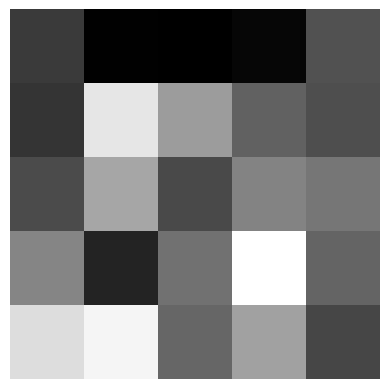

In [17]:
# let's plot the patch
plt.imshow(patch_g, cmap='gray')
plt.axis('off')
plt.show()

# 2D Convolution

Now that we understand what the image is made of, it is simple to conceptualise it as a function that maps pixel locations to color intensities.
Let's call out image function $I(x, y)$ where x and y are the pixel coordinates. For a grayscale image, $I(x, y)$ returns a single intensity value $(0-1)$, while for a color image it returns a vector of three values (R, G, B). 

Our kernels -or filters- can also be considered as 2d functions that map pixel locations within their receptive field to weights. For example, a 3x3 filter $K(u, v)$ maps the 9 pixel locations within its 3x3 window to 9 weight values.

Through 2D convolution, we slide the filter $K(u, v)$ over the image $I(x, y)$, computing a weighted sum of pixel intensities within the filter's receptive field at each position. This operation produces a new image (feature map) that highlights specific features based on the filter's weights.
Mathematically, the convolution operation can be expressed as:
$$
O(x, y) = \sum_{u=0}^{m-1} \sum_{v=0}^{n-1} K(u, v) \cdot I(x+u, y+v)
$$
Where: 
- $O(x, y)$ is the output feature map.
- $K(u, v)$ is the filter kernel of size m x n.

Let's now build a simple 2D CNN using the concepts we have learned so far. We will modify our previous functions to handle 2D convolutions and pooling, finally creating a 2D CNN architecture.

To implement the `apply_convolution_2d` function, you will need to iterate over both dimensions (2 `for` loops) of the input image and perform convolution with the kernels. 

In [ ]:
def apply_2D_convolution(input_data, filters, stride=1):
    """
    Apply convolution on a 3D input (2D image + channels) using given filters.

    Parameters:
    - input_data: 3D numpy array, the input data (channels, height, width)
    - filters: List of 3D numpy arrays, representing the filters
    - stride: Integer, the stride of the convolution operation

    Returns:
    - output: 3D numpy array, the result of convolution
    """

    # If input_data is 3D, ensure filters are the right shape
    ## YOUR CODE HERE (Hint: assert might be useful here)

    # Initialize an empty array to store the convolution result
    output_h = ## YOUR CODE HERE
    output_w = ## YOUR CODE HERE
    num_filters = len(filters)
    output = np.zeros((num_filters, output_h, output_w))

    # Perform convolution with the specified stride
    for i in range(output_h):
        for j in range(output_w):
            output[:, i, j] = ## YOUR CODE HERE

    return output

In [19]:
# quick debug
input_data = np.random.rand(3, 10, 10)  # Example input data with 3 channels and img size 10x10
filters = [np.random.rand(3, 3, 3) for _ in range(2)]
output = apply_2D_convolution(input_data, filters, stride=2)

out_len = (input_data.shape[1] - filters[0].shape[1]) // 2 + 1
out_wid = (input_data.shape[2] - filters[0].shape[2]) // 2 + 1

print(output.shape[1] == out_len) # Should be True
print(output.shape[2] == out_wid) # Should be True
print("Expected output length:", out_len)
print("Expected output width:", out_wid)
print("Output shape:", output.shape) # Should be (number of filters, output length, output width)
print("Output:", output) # Display the output array

True
True
Expected output length: 4
Expected output width: 4
Output shape: (2, 4, 4)
Output: [[[5.86 5.58 7.18 7.57]
  [6.65 5.69 5.98 7.12]
  [5.46 5.92 6.77 7.25]
  [7.28 7.91 6.45 5.95]]

 [[6.39 6.3  6.44 8.42]
  [7.44 7.11 7.68 6.95]
  [6.12 5.43 7.12 7.22]
  [8.25 7.61 7.13 7.68]]]


Let's now test our 2D convolution function with our sample image and filter.

## Sobel Filter
Sobel is very common operator to detect edges of an image, which is an approximation to a derivative of an image.It is separate in the $y$ and $x$ directions. Here We use a kernel 3*3 matrix, one for each $x$ and $y$ direction. The gradient for $x$-direction has minus numbers on the left and positive numbers on the right and we are preserving the center pixels.Similarly, the gradient for $y$-direction has minus numbers on the bottom and positive numbers on top and here we the middle row pixels.

![Sobel Filter Illustration](sobel_con_kernels.png)

In [ ]:
# Apply sobel operator 
# Define Sobel filters for x and y directions (add channel dimension)
sobel_x = np.array([[[-1, 0, 1],
                     [-2, 0, 2],
                     [-1, 0, 1]]])  # Shape: (1, 3, 3)
sobel_y = np.array([[[1, 2, 1],
                     [0, 0, 0],
                     [-1, -2, -1]]])  # Shape: (1, 3, 3)
filters_x = [sobel_x]
filters_y = [sobel_y]

# Add channel dimension to grayscale image: (H, W) -> (1, H, W)
img_gray_3d = ## YOUR CODE HERE (Hint: reshape or np.newaxis)

# Convolve the grayscale image with Sobel filters
grad_x = apply_2D_convolution(img_gray_3d, filters_x)
grad_y = apply_2D_convolution(img_gray_3d, filters_y)

# Compute the gradient magnitude
gradient_magnitude = np.sqrt(grad_x**2 + grad_y**2)
# Normalize the gradient magnitude to [0, 1]
gradient_magnitude = gradient_magnitude / np.max(gradient_magnitude)

# Plot the results (squeeze to remove channel dim for plotting)
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.title('Original Grayscale Image')
plt.imshow(img_gray, cmap='gray')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.title('Sobel Gradient X')
plt.imshow(grad_x[0], cmap='gray')  # Index [0] to get first filter output
plt.axis('off')
plt.subplot(1, 3, 3)
plt.title('Sobel Gradient Y')
plt.imshow(grad_y[0], cmap='gray')  # Index [0] to get first filter output
plt.axis('off')
plt.figure()
plt.title('Sobel Gradient Magnitude')
plt.imshow(gradient_magnitude[0], cmap='gray')  # Index [0] to get first filter output
plt.axis('off')
plt.show()

NameError: name 'np' is not defined

## Prewitt Filter
Prewitt operator is similar to the Sobel operator and is used for detecting vertical and horizontal edges in images. It provides us two masks one for detecting edges in horizontal direction and another for detecting edges in an vertical direction.

![Prewitt Filter Illustration](prewitt's_kernel.png)

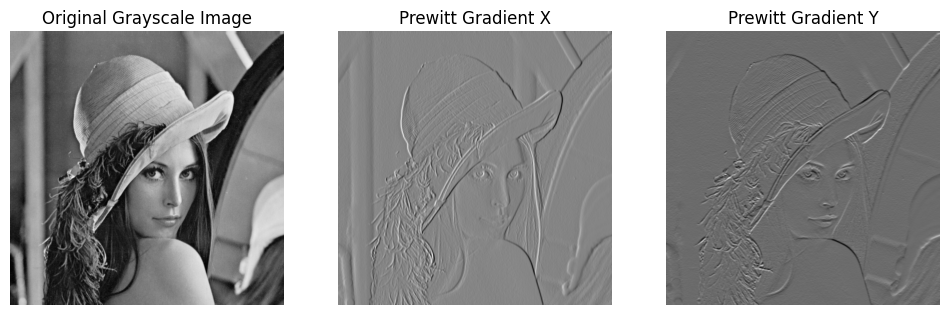

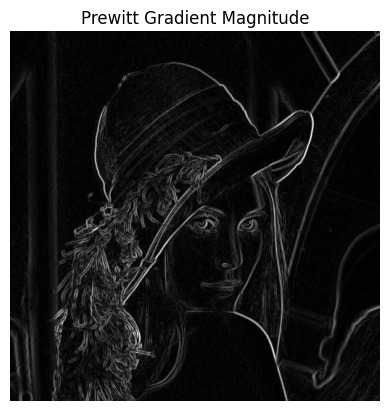

In [21]:
# Prewitt operator
# Define Prewitt filters for x and y directions
prewitt_x = np.array([[[-1, 0, 1],
                        [-1, 0, 1],
                        [-1, 0, 1]]])
prewitt_y = np.array([[[1, 1, 1],
                      [0, 0, 0],
                      [-1, -1, -1]]])

# Add channel dimension to Prewitt filters: (H, W) -> (1, H, W)
prewitt_x = [prewitt_x]
prewitt_y = [prewitt_y]

# Convolve the grayscale image with Prewitt filters
grad_x = apply_2D_convolution(img_gray_3d, prewitt_x)
grad_y = apply_2D_convolution(img_gray_3d, prewitt_y)
# Compute the gradient magnitude
gradient_magnitude = np.sqrt(grad_x**2 + grad_y**2)
# Normalize the gradient magnitude to [0, 1]
gradient_magnitude = gradient_magnitude / np.max(gradient_magnitude)
# Plot the results
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.title('Original Grayscale Image')
plt.imshow(img_gray, cmap='gray')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.title('Prewitt Gradient X')
plt.imshow(grad_x[0], cmap='gray')  # Index [0] to get first filter output
plt.axis('off')
plt.subplot(1, 3, 3)
plt.title('Prewitt Gradient Y')
plt.imshow(grad_y[0], cmap='gray')  # Index [0] to get first filter output
plt.axis('off')
plt.figure()
plt.title('Prewitt Gradient Magnitude')
plt.imshow(gradient_magnitude[0], cmap='gray')  # Index [0] to get first filter output
plt.axis('off')
plt.show()

## 2D Pooling
Let's now implement 2D Pooling. 

In [ ]:
#2d pooling
def apply_2D_pooling(input_data, pool_size, stride=1):
    """
    Apply 2D pooling on the input data.

    Parameters:
    - input_data: 3D numpy array, the input data (channels, height, width)
    - pool_size: Integer, size of the pooling window
    - stride: Integer, the stride of the pooling operation

    Returns:
    - result: 3D numpy array, the result after pooling
    """
    # Ensure the input is a 3D array
    ## YOUR CODE HERE

    # Calculate the output dimensions after pooling
    output_h = ## YOUR CODE HERE
    output_w = ## YOUR CODE HERE

    # Initialize an empty array to store the pooling result
    result = ## YOUR CODE HERE

    # Perform 2D pooling with the specified stride
    for i in range(output_h):
        for j in range(output_w):
            result[:, i, j] = ## YOUR CODE HERE
    return result

In [23]:
# quick debug
input_data = np.random.rand(2, 10, 10)  # Example input
pool_size = 3
stride = 2
output = apply_2D_pooling(input_data, pool_size, stride)
expected_out_len = (input_data.shape[1] - pool_size) // stride + 1
expected_out_wid = (input_data.shape[2] - pool_size) // stride + 1
print(output.shape[1] == expected_out_len)  # Should be True
print(output.shape[2] == expected_out_wid)  # Should be True
print("Expected output length:", expected_out_len)
print("Expected output width:", expected_out_wid)
print("Output shape:", output.shape)  # Should be (num_channels, output_length, output_width)
print("Output:", output)  # Display the output array

True
True
Expected output length: 4
Expected output width: 4
Output shape: (2, 4, 4)
Output: [[[0.9  0.99 0.97 0.81]
  [0.9  0.9  0.93 0.93]
  [0.95 0.95 0.97 0.99]
  [0.87 0.71 0.97 0.65]]

 [[0.99 0.99 0.96 0.87]
  [0.73 0.9  0.99 0.99]
  [0.98 0.88 0.88 0.94]
  [0.96 0.7  0.81 0.98]]]


Pooled gradient shape: (1, 255, 255)
Original gradient shape: (1, 510, 510)


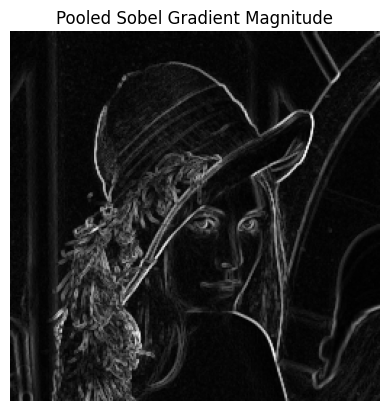

In [24]:
# plotting the pooled gradient magnitude from sobel operator
pooled_gradient = apply_2D_pooling(gradient_magnitude, pool_size=2, stride=2)

print("Pooled gradient shape:", pooled_gradient.shape)
print("Original gradient shape:", gradient_magnitude.shape)

plt.figure()
plt.title('Pooled Sobel Gradient Magnitude')
plt.imshow(pooled_gradient[0], cmap='gray') 
plt.axis('off')
plt.show()

## 2D CNN

Finally, let's put all pieces together to develop a 2D CNN

In [25]:
def two_dimensional_cnn(input_data, filters_layer1, filters_layer2, pool_size, conv_stride=1, pool_stride=1):
    """
    Create a 2D CNN with two convolutional layers, ReLU activation, and pooling.

    Parameters:
    - input_data: 3D numpy array, the input data (channels, height, width)
    - filters_layer1: List of 3D numpy arrays, filters for the first convolutional layer
    - filters_layer2: List of 3D numpy arrays, filters for the second convolutional layer
    - pool_size: Integer, size of the pooling window

    Returns:
    - output: 3D numpy array, the final output of the CNN
    """
    # Apply convolution and ReLU activation for the first layer
    layer1_output = apply_2D_convolution(input_data, filters_layer1, conv_stride)
    layer1_output_relu = apply_relu(layer1_output)
    layer1_output_pooled = apply_2D_pooling(layer1_output_relu, pool_size, pool_stride)

    # Apply convolution and ReLU activation for the second layer
    layer2_output = apply_2D_convolution(layer1_output_pooled, filters_layer2, conv_stride)
    layer2_output_relu = apply_relu(layer2_output)
    layer2_output_pooled = apply_2D_pooling(layer2_output_relu, pool_size, pool_stride)

    np.set_printoptions(precision=2, suppress=True)
    print(f"Input data shape: {input_data.shape}\n")
    print(f"Output convolution 1 shape: {layer1_output.shape}")
    print(f"Pooling 1 shape: {layer1_output_pooled.shape}\n")
    print(f"Output convolution 2 shape: {layer2_output.shape}")
    print(f"Pooling 2 shape: {layer2_output_pooled.shape}\n")

    return layer2_output_pooled

In [ ]:
# let's try to see how the combination of filters works in a 2D CNN

output = two_dimensional_cnn(img_gray_3d, ## YOUR CODE HERE)

# show the final output
plt.figure()
plt.title('Final Output of 2D CNN')
plt.imshow(output[0], cmap='gray')  # Index [0] to get first
plt.axis('off')
plt.show()

Well done! You made it to the end of this notebook. You have implemented a simple CNN from scratch and explored how convolutional filters work on images.

In the resulting magnitude images, you should observe that both Sobel and Prewitt filters effectively highlight the edges in the original image. The areas with significant intensity changes, such as object boundaries, appear brighter in the output images, indicating strong edge responses. This demonstrates the capability of these filters to detect edges by emphasizing regions with high gradients while suppressing uniform areas. Overall, the results confirm that both Sobel and Prewitt filters are effective tools for edge detection in image processing tasks.

More on this topic can be found in the following resources:
https://ai.stanford.edu/~syyeung/cvweb/tutorial1.html